<a href="https://colab.research.google.com/github/Doumbia07/DI_Bootcamp/blob/main/ExercisesXPGold_KMeans_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Dataset chargé avec pandas
Shape : (569, 31)

 Premières lignes du dataset :
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fracta

/tmp/ipykernel_30431/19502928.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='magma')


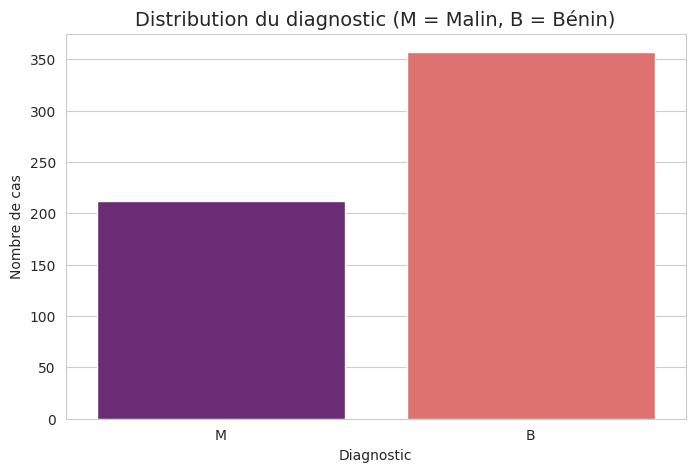


 Nombre de valeurs uniques dans 'diagnosis' : 2
Valeurs uniques : ['M' 'B']
Détail des comptes :
diagnosis
B    357
M    212
Name: count, dtype: int64

 Mapping effectué : M -> 1, B -> 0
  diagnosis  diagnosis_num
0         M              1
1         M              1
2         M              1
3         M              1
4         M              1

Taille train : (455, 30)
Taille test  : (114, 30)

 Logistic Regression accuracy : 0.9649
 K-Nearest Neighbours accuracy : 0.9561
 Random Forest accuracy : 0.9737
 SVM accuracy : 0.9737

 MEILLEUR MODÈLE : Random Forest avec une accuracy de 0.9737
   Random Forest: 0.9737
   SVM: 0.9737
   Logistic Regression: 0.9649
   KNN: 0.9561


In [10]:
# 1. IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Pour reproduire les résultats
np.random.seed(42)


# 2. CHARGEMENT DU DATASET

from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target
# Le dataset original a 'M'/'B', transformons-le pour respecter le mapping
df['diagnosis'] = df['diagnosis'].map({0: 'M', 1: 'B'})

print(" Dataset chargé avec pandas")
print(f"Shape : {df.shape}")


# 3. EXAMEN DES PREMIÈRES LIGNES

print("\n Premières lignes du dataset :")
print(df.head())


# 4. VÉRIFICATION DES VALEURS MANQUANTES

print("\n Valeurs manquantes par colonne :")
print(df.isnull().sum())

# Il n'y a aucune valeur manquante dans ce dataset
# Si besoin, on pourrait les supprimer : df.dropna(inplace=True)


# 5. SUPPRESSION D'UNE COLONNE INUTILE (si elle existe)

# Le dataset ne contient pas de colonne 'id' ou autre inutile.
# Mais pour respecter la consigne, on vérifie et on supprime si présente.
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    print("Colonne 'id' supprimée")
else:
    print("Aucune colonne inutile à supprimer (pas de colonne 'id' ou similaire)")


# 6. COUNTPLOT AVEC PALETTE MAGMA

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='diagnosis', palette='magma')
plt.title("Distribution du diagnostic (M = Malin, B = Bénin)", fontsize=14)
plt.xlabel("Diagnostic")
plt.ylabel("Nombre de cas")
plt.show()


# 7. COMPTER LES VALEURS UNIQUES DANS 'diagnosis'

print("\n Nombre de valeurs uniques dans 'diagnosis' :", df['diagnosis'].nunique())
print("Valeurs uniques :", df['diagnosis'].unique())
print("Détail des comptes :")
print(df['diagnosis'].value_counts())


# 8. MAPPING CATÉGORICAL -> NUMÉRIQUE

# Selon la consigne : 'M' -> 1 (malin) ? ou l'inverse ? On choisit classique : M=1 (malin), B=0 (bénin)
mapping = {'M': 1, 'B': 0}
df['diagnosis_num'] = df['diagnosis'].map(mapping)
print("\n Mapping effectué : M -> 1, B -> 0")
print(df[['diagnosis', 'diagnosis_num']].head())


# 9. SÉPARATION DES FEATURES (X) ET DE LA CIBLE (y)

X = df.drop(['diagnosis', 'diagnosis_num'], axis=1)  # toutes les features sauf la cible
y = df['diagnosis_num']  # cible numérique


# 10. SPLIT TRAIN / TEST (80% / 20%)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTaille train : {X_train.shape}")
print(f"Taille test  : {X_test.shape}")


# 11. STANDARDISATION (recommandée pour LR, KNN, SVM)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 12. IMPLÉMENTATION DES MODÈLES ET AFFICHAGE DE L'ACCURACY


results = {}

#  Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=2000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
results['Logistic Regression'] = acc_lr
print(f"\n Logistic Regression accuracy : {acc_lr:.4f}")

#  K-Nearest Neighbours
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
results['KNN'] = acc_knn
print(f" K-Nearest Neighbours accuracy : {acc_knn:.4f}")

#  Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)  # Random Forest n'a pas besoin de scaling
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
results['Random Forest'] = acc_rf
print(f" Random Forest accuracy : {acc_rf:.4f}")

#  Support Vector Machine
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
results['SVM'] = acc_svm
print(f" SVM accuracy : {acc_svm:.4f}")


# 13. QUEL EST LE MEILLEUR MODÈLE ?

best_model = max(results, key=results.get)
best_acc = results[best_model]
print("\n" + "="*50)
print(f" MEILLEUR MODÈLE : {best_model} avec une accuracy de {best_acc:.4f}")


# Affichage du classement complet
for modele, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"   {modele}: {acc:.4f}")